# **Analytical Question 3**

### **Model 3 (Autoencoder with Regression)**

## **Proofs or Evidences**

#### **Imports**

In [1]:
import numpy as np
import pandas as pd
import os

#### **Load Dataset**

In [2]:
CSV_PATH = "Group2_ABT.csv"
OUT_DIR = "./outputs_proof"

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH, on_bad_lines="skip", low_memory=False)
pm_col = [c for c in df.columns if "pm25 in µg/m^3" in c.lower()][0]

df["datetime_utc"] = pd.to_datetime(df["datetime_utc"], errors="coerce")
df = df.dropna(subset=["datetime_utc", "station"])
df[pm_col] = pd.to_numeric(df[pm_col], errors="coerce")
df = df.sort_values(["station", "datetime_utc"]).reset_index(drop=True)

print(f"Loaded {len(df):,} rows from {df["station"].nunique()} stations")


Loaded 1,027,171 rows from 97 stations


#### **Time Gaps**

In [3]:
df["gap_min"] = df.groupby("station")["datetime_utc"].diff().dt.total_seconds()/60
gaps = df.dropna(subset=["gap_min"])

station_stats = gaps.groupby("station")["gap_min"].agg(
    n_records = "count",
    median_gap_min = "median",
    p75_gap_min = lambda x: x.quantile(0.75),
    p90_gap_min = lambda x: x.quantile(0.90),
    p95_gap_min = lambda x: x.quantile(0.95),
    mean_gap_min = "mean",
).round(2)

station_stats.to_csv(f"{OUT_DIR}/TimeGaps.csv")
print("====== TIME GAPS PER STATION ======")
display(station_stats.describe().round(2))

====== TIME GAPS PER STATION ======


,n_records,median_gap_min,p75_gap_min,p90_gap_min,p95_gap_min,mean_gap_min
count,96.00,96.00,96.00,96.00,96.00,96.00
mean,10698.69,30.72,33.00,54.53,116.77,89.28
std,6983.14,23.13,33.47,120.36,245.52,237.22
min,1.00,5.58,5.60,5.60,5.82,7.51
25%,2497.25,11.30,14.64,17.09,60.00,23.83
50%,13642.00,17.33,17.38,17.48,60.29,24.80
75%,16999.00,60.00,60.00,60.00,69.04,64.33
max,16999.00,60.00,270.00,810.00,1458.00,1783.36


#### **Median Gaps per station across different time targets**
*What percentage of our stations are reporting data at or faster than X minutes?*

In [4]:
print("====== Share of Stations at Candidate Thresholds ======")
for thr in [5, 10, 15, 20, 30, 40, 50, 60]:
    share = (station_stats["median_gap_min"] <= thr).mean()
    print(f"  Median Gap <= {thr:>3} min: {share:6.2%} of stations")

====== Share of Stations at Candidate Thresholds ======
  Median Gap <=   5 min:  0.00% of stations
  Median Gap <=  10 min: 25.00% of stations
  Median Gap <=  15 min: 26.04% of stations
  Median Gap <=  20 min: 62.50% of stations
  Median Gap <=  30 min: 62.50% of stations
  Median Gap <=  40 min: 62.50% of stations
  Median Gap <=  50 min: 62.50% of stations
  Median Gap <=  60 min: 100.00% of stations


#### **Per Station Coverage: 20 minutes vs 1 hour**

In [5]:
print("=" * 72)
print("COVERAGE: 20 min vs 1 h  (per-station, own active period)")
print("=" * 72)

CANDIDATES = ['20min', '1h']

# ---- Step 1: classify stations by native cadence cluster ----
def cadence_cluster(median_gap):
    if median_gap <= 10:
        return 'A_high_freq'      # ~5.7–8.0 min
    if median_gap <= 20:
        return 'B_candidate'     # ~15-20 min
    return 'C_hourly'             # 60 min

station_stats['cluster'] = station_stats['median_gap_min'].apply(cadence_cluster)

cluster_sizes = station_stats['cluster'].value_counts()
print("\nCluster sizes:")
for cl in ['A_high_freq', 'B_candidate', 'C_hourly']:
    if cl not in cluster_sizes: continue
    n = cluster_sizes[cl]
    print(f"  {cl:>15}: {n:>3} stations  ({n/len(station_stats):>5.1%})")

# ---- Step 2: per-station coverage on own active period ----
coverage_records = []
for station, group in df.groupby('station'):
    if station not in station_stats.index:
        continue

    cluster = station_stats.loc[station, 'cluster']
    t0, t1 = group['datetime_utc'].min(), group['datetime_utc'].max()
    g = group.set_index('datetime_utc')[pm_col].sort_index()

    row = {
        'station':      station,
        'cluster':      cluster,
        'n_records':    len(g),
        'active_hours': (t1 - t0).total_seconds() / 3600,
    }
    for res in CANDIDATES:
        s = g.resample(res).mean()
        row[f'coverage_{res}'] = float(s.notna().mean())
    coverage_records.append(row)

coverage_df = pd.DataFrame(coverage_records).set_index('station')

# ---- Step 3: mean coverage per cluster ----
print("\n" + "-" * 72)
print("Mean coverage per cluster")
print("-" * 72)
agg = coverage_df.groupby('cluster')[[f'coverage_{r}' for r in CANDIDATES]].mean()
print(agg.round(3).to_string())

# ---- Step 4: network-weighted coverage ----
print("\n" + "-" * 72)
print("Network-weighted mean coverage")
print("-" * 72)
weights = cluster_sizes / cluster_sizes.sum()
weighted = (agg.T * weights).T.sum()
for res in CANDIDATES:
    print(f"  {res:>5}: {weighted[f'coverage_{res}']:.3f}")

# ---- Step 5: fraction of stations at >= 0.95 coverage ----
print("\n" + "-" * 72)
print("Fraction of stations with coverage >= 0.95")
print("-" * 72)
for res in CANDIDATES:
    col = f'coverage_{res}'
    n = (coverage_df[col] >= 0.95).sum()
    print(f"  {res:>5}: {n:>3}/{len(coverage_df)} stations ({n/len(coverage_df):.1%})")

# ---- Step 6: which clusters are well-served at each resolution ----
print("\n" + "-" * 72)
print("Stations with coverage >= 0.95, by cluster")
print("-" * 72)
for cl in ['A_high_freq', 'B_candidate', 'C_hourly']:
    subset = coverage_df[coverage_df['cluster'] == cl]
    if len(subset) == 0: continue
    print(f"\n  {cl}  (n = {len(subset)}):")
    for res in CANDIDATES:
        col = f'coverage_{res}'
        n = (subset[col] >= 0.95).sum()
        print(f"    {res:>5}: {n:>3}/{len(subset)} ({n/len(subset):.1%})")

# ---- Step 7: side-by-side per-station table (top 15 by 20-min gap) ----
print("\n" + "-" * 72)
print("Stations where 20 min gains the most over 1 h")
print("-" * 72)
coverage_df['gain_20min_over_1h'] = (
    coverage_df['coverage_20min'] - coverage_df['coverage_1h']
)
top_gain = coverage_df.sort_values('gain_20min_over_1h', ascending=False).head(15)
print(top_gain[['cluster', 'coverage_20min', 'coverage_1h',
                'gain_20min_over_1h']].round(3).to_string())

# ---- Step 8: save ----
coverage_df.to_csv(f'{OUT_DIR}/coverage_20min_vs_1h_per_station.csv')
agg.to_csv(f'{OUT_DIR}/coverage_20min_vs_1h_per_cluster.csv')
print(f"\nSaved:")
print(f"  {OUT_DIR}/coverage_20min_vs_1h_per_station.csv")
print(f"  {OUT_DIR}/coverage_20min_vs_1h_per_cluster.csv")

COVERAGE: 20 min vs 1 h  (per-station, own active period)

Cluster sizes:
      A_high_freq:  24 stations  (25.0%)
      B_candidate:  36 stations  (37.5%)
         C_hourly:  36 stations  (37.5%)

------------------------------------------------------------------------
Mean coverage per cluster
------------------------------------------------------------------------
             coverage_20min  coverage_1h
cluster                                 
A_high_freq           0.540        0.638
B_candidate           0.717        0.767
C_hourly              0.252        0.732

------------------------------------------------------------------------
Network-weighted mean coverage
------------------------------------------------------------------------
  20min: 0.498
     1h: 0.722

------------------------------------------------------------------------
Fraction of stations with coverage >= 0.95
------------------------------------------------------------------------
  20min:   0/96 stations (0

In [6]:
from scipy.interpolate import interp1d

for res in ['20min', '1h']:
    errors = []
    for station, group in df.groupby('station'):
        g = group.set_index('datetime_utc')[pm_col].sort_index()
        coarse = g.resample(res).mean().dropna()
        if len(coarse) < 10: continue
        # Interpolate coarse back to original timestamps
        f = interp1d(coarse.index.astype('int64'), coarse.values,
                     kind='linear', fill_value='extrapolate')
        reconstructed = f(g.index.astype('int64'))
        errors.append(np.sqrt(np.mean((g.values - reconstructed) ** 2)))
    print(f"{res}: mean reconstruction RMSE = {np.mean(errors):.3f}")

20min: mean reconstruction RMSE = 3.731
1h: mean reconstruction RMSE = 4.807


## **Modeling: AER with Regression**

##### **Installs Necessary Packages**

In [7]:
import sys
import subprocess

def auto_install(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"{package_name} is missing! Installing it now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        print(f"{package_name} successfully installed.")

auto_install("tensorflow")
auto_install("scikit-learn", import_name="sklearn")
auto_install("scipy")
auto_install("pandas")

#### **Imports**

In [8]:
import os
import json
import time
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d

In [9]:
OUT_DIR = "./outputs_aer"
os.makedirs(OUT_DIR, exist_ok=True)

#### **AER Model Configurations**

In [10]:
RESAMPLE = "20min"

N_STEPS          = 48
B_UNITS          = 30
GAMMA            = 0.5
MASK_RATIO       = 0.01
EWMA_SPAN_RATIO  = 0.1
THRESH_SIG       = 4.0
COMBINE          = 'MULT'

# Training
EPOCHS      = 5
BATCH       = 256
TRAIN_FRAC  = 0.8
VAL_SPLIT   = 0.1

# Extensions
USE_FFT_CHANNELS = True
FFT_KEEP_RATIO   = 0.10

# Station gating (from coverage evidence)
MAX_TRAIN_WINDOWS = 8000     
MIN_N_RECORDS      = 500
MIN_COVERAGE_20MIN = 0.30
MIN_TRAIN_WINDOWS  = 100

# Risk aggregation weights
RISK_WEIGHTS = {
    'downtime_ratio':                 0.25,
    'max_continuous_downtime_hours':  0.15,
    'anomaly_freq':                   0.25,
    'anomaly_days_ratio':             0.15,
    'mean_anomaly_score':             0.10,
    'fft_energy':                     0.05,
    'fft_spectral_entropy':           0.05,
}

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("=" * 76)
print("AER PIPELINE — PM2.5 Sensor-Maintenance Prioritization")
print("=" * 76)
print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Resolution : {RESAMPLE}  (n={N_STEPS} → {N_STEPS * 20 / 60:.1f} h window)")
print(f"AER        : b={B_UNITS}, γ={GAMMA}, combine={COMBINE}")
print("=" * 76)

AER PIPELINE — PM2.5 Sensor-Maintenance Prioritization
TensorFlow : 2.22.0-rc0
GPU        : False
Resolution : 20min  (n=48 → 16.0 h window)
AER        : b=30, γ=0.5, combine=MULT


#### **Cadence Clusters**

In [11]:
def cadence_cluster(med):
    if med <= 10:  return 'A_high_freq'
    if med <= 20:  return 'B_candidate'
    return 'C_hourly'

cadence = station_stats.copy()
cadence['cluster']      = cadence['median_gap_min'].apply(cadence_cluster)
cadence['irregularity'] = cadence['p95_gap_min'] / cadence['median_gap_min'].clip(lower=1e-6)

cluster_counts = cadence['cluster'].value_counts()
print("\nCadence clusters:")
for cl in ['A_high_freq', 'B_candidate', 'C_hourly']:
    if cl in cluster_counts:
        n = cluster_counts[cl]
        print(f"    {cl:<16} {n:>3} stations ({n/len(cadence):.1%})")


Cadence clusters:
    A_high_freq       24 stations (25.0%)
    B_candidate       36 stations (37.5%)
    C_hourly          36 stations (37.5%)


#### **Resample to 20 Minutes**

In [12]:
print(f"\nResampling to {RESAMPLE} ...")

df_res = (df.set_index('datetime_utc')
            .groupby('station')
            .resample(RESAMPLE)
            .agg({pm_col: 'mean'})
            .reset_index())

pivot = df_res.pivot(index='datetime_utc', columns='station',
                     values=pm_col).sort_index()

hours_per_bin = pd.Timedelta(RESAMPLE).total_seconds() / 3600.0
print(f"    Grid: {pivot.shape[0]:,} bins × {pivot.shape[1]} stations")
print(f"    Bin width: {hours_per_bin:.3f} h")


Resampling to 20min ...
    Grid: 78,732 bins × 97 stations
    Bin width: 0.333 h


#### **Station Gating**

In [13]:
print("\nStation gating ...")

cov_rows = []
for st in pivot.columns:
    s = pivot[st].dropna()
    if len(s) < 2:
        cov_rows.append({'station': st, 'n_bins': 0,
                         'active_bins': 0, 'coverage': 0.0})
        continue
    t0, t1 = s.index.min(), s.index.max()
    span = max(1, int((t1 - t0) / pd.Timedelta(RESAMPLE)) + 1)
    cov_rows.append({'station': st, 'n_bins': len(s),
                     'active_bins': span, 'coverage': len(s) / span})

coverage_df = pd.DataFrame(cov_rows).set_index('station')
coverage_df = coverage_df.join(
    cadence[['cluster', 'median_gap_min', 'irregularity']], how='left')

keep = (coverage_df['n_bins'] >= MIN_N_RECORDS) & \
       (coverage_df['coverage'] >= MIN_COVERAGE_20MIN)
excluded = coverage_df[~keep].copy()
excluded['reason'] = np.where(
    coverage_df.loc[~keep, 'n_bins'] < MIN_N_RECORDS, 'low_n_records',
    'low_coverage')

valid_stations = coverage_df.index[keep].tolist()
pivot       = pivot[valid_stations]
coverage_df = coverage_df.loc[valid_stations]

print(f"    Kept     : {len(valid_stations)} / {len(cov_rows)}")
print(f"    Excluded : {len(excluded)}  ({excluded['reason'].value_counts().to_dict()})")
excluded.to_csv(f'{OUT_DIR}/excluded_stations.csv')


Station gating ...
    Kept     : 67 / 97
    Excluded : 30  ({'low_n_records': 18, 'low_coverage': 12})


#### **Downtime Metrics**

In [14]:
print("\nDowntime metrics (cadence-adjusted, per-station active period) ...")

median_gap = cadence.reindex(pivot.columns)['median_gap_min'].values
expected_coverage = np.minimum(1.0, 20.0 / median_gap)

# Actual coverage measured earlier in the station-gating cell
actual_coverage = coverage_df['coverage'].reindex(pivot.columns).values

# 1.0 = perfectly healthy cadence,
# 0.0 = fully offline. Values between = partial outages.
adjusted_coverage = np.clip(actual_coverage / expected_coverage, 0.0, 1.0)

downtime_ratio = pd.Series(
    1.0 - adjusted_coverage,
    index=pivot.columns,
    name='downtime_ratio',
)


# Outage duration: only gaps LARGER than the cadence count as outages.
# A gap of 17 min between readings from a 17-min station is normal.
# A gap of 6 hours is an outage.# -------------------------------------------------------------
def outage_stats(series, expected_gap_min):
    """Return (max_outage_hours, total_outage_hours) for one station."""
    valid = series.dropna()
    if len(valid) < 2:
        return 0.0, 0.0

    gaps_min = valid.index.to_series().diff().dt.total_seconds().dropna() / 60
    threshold = 3.0 * expected_gap_min    # 3× cadence = start of outage
    long_gaps = gaps_min[gaps_min > threshold]

    if len(long_gaps) == 0:
        return 0.0, 0.0

    # Subtract the expected cadence from each gap to isolate "extra" outage time
    extra_min = (long_gaps - expected_gap_min)
    return float(extra_min.max() / 60.0), float(extra_min.sum() / 60.0)


max_outage, total_outage = {}, {}
for st in pivot.columns:
    gap_min = cadence.loc[st, 'median_gap_min']
    mx, tot = outage_stats(pivot[st], gap_min)
    max_outage[st]  = mx
    total_outage[st] = tot

downtime = pd.DataFrame({
    'downtime_ratio':                downtime_ratio,
    'max_continuous_downtime_hours': pd.Series(max_outage,   name='max_continuous_downtime_hours'),
    'total_downtime_hours':          pd.Series(total_outage, name='total_downtime_hours'),
})


print(f"    Downtime ratio      : mean={downtime['downtime_ratio'].mean():.3f}  "
      f"median={downtime['downtime_ratio'].median():.3f}  "
      f"max={downtime['downtime_ratio'].max():.3f}")
print(f"    Max outage (hours)  : mean={downtime['max_continuous_downtime_hours'].mean():.1f}  "
      f"max={downtime['max_continuous_downtime_hours'].max():.1f}")
print(f"    Total outage (hours): mean={downtime['total_downtime_hours'].mean():.1f}  "
      f"max={downtime['total_downtime_hours'].max():.1f}")

# Show the top 5 worst stations by downtime ratio as a preview
print("\n    Top 5 by downtime ratio:")
print(downtime['downtime_ratio'].sort_values(ascending=False).head(5).round(3).to_string())


Downtime metrics (cadence-adjusted, per-station active period) ...
    Downtime ratio      : mean=0.268  median=0.286  max=0.583
    Max outage (hours)  : mean=54.9  max=735.5
    Total outage (hours): mean=1478.0  max=2370.9

    Top 5 by downtime ratio:
Boni Serrano                0.583
Near Puregold Tayuman       0.485
Sta. Ana Hospital           0.485
Anda Circle                 0.485
San Sebastian Residences    0.483


In [15]:
print("Mean imputation ...")
pivot_imp = pivot.fillna(pivot.mean())

Mean imputation ...


In [16]:
def detrend(x):
    """Least-squares linear detrend — paper Sec III-A."""
    t = np.arange(len(x), dtype=float)
    A = np.vstack([t, np.ones_like(t)]).T
    coef, *_ = np.linalg.lstsq(A, x, rcond=None)
    return x - (A @ coef)

def scale_neg1_1(x):
    """Min-max to [-1, 1] — paper Sec III-A."""
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-12:
        return np.zeros_like(x)
    return 2.0 * (x - mn) / (mx - mn) - 1.0

def build_fft_channels(x_detrended, keep_ratio=FFT_KEEP_RATIO):
    """Split detrended signal into [raw, seasonal, residual] via FFT low-pass."""
    n = len(x_detrended)
    fft = np.fft.rfft(x_detrended)
    k = max(1, int(len(fft) * keep_ratio))
    filt = fft.copy(); filt[k:] = 0.0
    seasonal = np.fft.irfft(filt, n=n)
    residual = x_detrended - seasonal
    return np.column_stack([x_detrended, seasonal, residual])

def make_windows(arr, n_steps, train_frac, max_windows=MAX_TRAIN_WINDOWS):
    T = arr.shape[0]
    split = int(T * train_frac)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(arr[:split])
    scaled = scaler.transform(arr).astype(np.float32)
    target = scaled[:, 0]

    X, Y = [], []
    for i in range(1, split - n_steps - 1):
        X.append(scaled[i:i + n_steps])
        y = np.zeros((n_steps + 2, 1), dtype=np.float32)
        y[0, 0]               = target[i - 1]
        y[1:n_steps + 1, 0]   = target[i:i + n_steps]
        y[n_steps + 1, 0]     = target[i + n_steps]
        Y.append(y)

    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)

    if len(X) > max_windows:
        idx = np.random.choice(len(X), max_windows, replace=False)
        X = X[idx]
        Y = Y[idx]

    return X, Y, scaled, scaler

def build_aer(n_steps, n_features, b=30, gamma=0.5):
    """AER model — paper Sec V-A, Eq. 5."""
    inp = Input(shape=(n_steps, n_features), name='aer_input')
    enc = layers.Bidirectional(layers.LSTM(b), name='encoder')(inp)
    dec = layers.RepeatVector(n_steps + 2, name='repeat_plus2')(enc)
    dec = layers.Bidirectional(
        layers.LSTM(b, return_sequences=True), name='decoder')(dec)
    out = layers.TimeDistributed(layers.Dense(1), name='output')(dec)
    model = Model(inp, out)

    def aer_loss(y_true, y_pred):
        rev_t, rec_t, fwd_t = (y_true[:, 0, 0],
                               y_true[:, 1:n_steps + 1, 0],
                               y_true[:, n_steps + 1, 0])
        rev_p, rec_p, fwd_p = (y_pred[:, 0, 0],
                               y_pred[:, 1:n_steps + 1, 0],
                               y_pred[:, n_steps + 1, 0])
        v_pred = 0.5 * tf.reduce_mean(tf.square(rev_t - rev_p)) \
               + 0.5 * tf.reduce_mean(tf.square(fwd_t - fwd_p))
        v_rec  = tf.reduce_mean(tf.square(rec_t - rec_p))
        return gamma * v_pred + (1.0 - gamma) * v_rec

    model.compile(optimizer='adam', loss=aer_loss)
    return model

def minmax01(x):
    x = np.nan_to_num(np.asarray(x, dtype=float), nan=0.0)
    mn, mx = x.min(), x.max()
    if mx - mn < 1e-12:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

def dynamic_threshold(scores, n_sigma=4.0):
    """Non-parametric dynamic threshold — paper Sec III-D."""
    s = np.asarray(scores, dtype=float)
    T = len(s)
    if T < 5:
        return np.zeros(T, dtype=bool)
    win = max(10, T // 3)
    step = max(1, win // 10)
    flags = np.zeros(T, dtype=bool)
    for start in range(0, T, step):
        end = min(start + win, T)
        w = s[start:end]
        if len(w) < 3:
            continue
        thr = w.mean() + n_sigma * w.std()
        flags[start:end] |= s[start:end] > thr
    return flags

def score_station(arr_scaled, model, n_steps, timestamps):
    """Bi-directional + reconstruction + combination — paper Sec V-B/C/D."""
    T = arr_scaled.shape[0]
    target = arr_scaled[:, 0]

    windows = np.stack([arr_scaled[i:i + n_steps]
                        for i in range(T - n_steps)], axis=0).astype(np.float32)
    preds = model.predict(windows, batch_size=512, verbose=0)

    alpha_fwd = np.full(T, np.nan)
    alpha_rev = np.full(T, np.nan)
    rec_buf   = [[] for _ in range(T)]

    for i in range(T - n_steps):
        rev_p = preds[i, 0, 0]
        rec_p = preds[i, 1:n_steps + 1, 0]
        fwd_p = preds[i, n_steps + 1, 0]

        if i + n_steps < T:
            alpha_fwd[i + n_steps] = abs(target[i + n_steps] - fwd_p)
        if i - 1 >= 0:
            alpha_rev[i - 1] = abs(target[i - 1] - rev_p)

        for j in range(n_steps):
            if i + j < T:
                rec_buf[i + j].append(rec_p[j])

    rec_med = np.array([np.median(v) if v else np.nan for v in rec_buf])
    alpha_rec = np.nan_to_num(np.abs(target - rec_med), nan=0.0)

    # Masking (Sec V-B)
    m = max(1, int(MASK_RATIO * T))
    alpha_fwd = np.nan_to_num(alpha_fwd, nan=0.0)
    alpha_rev = np.nan_to_num(alpha_rev, nan=0.0)
    alpha_fwd[:m] = 0.0
    if len(alpha_rev):
        alpha_rev[:m] = alpha_rev.min()

    # Bi-directional (Eq. 6)
    alpha_b = np.zeros(T)
    for i in range(T):
        if   i < n_steps + m:   alpha_b[i] = alpha_rev[i]
        elif i < T - n_steps:   alpha_b[i] = 0.5 * alpha_rev[i] + 0.5 * alpha_fwd[i]
        else:                   alpha_b[i] = alpha_fwd[i]

    # Combination (Eq. 7–10)
    b01, r01 = minmax01(alpha_b), minmax01(alpha_rec)
    if   COMBINE == 'MULT': alpha_c = (r01 + 1.0) * (b01 + 1.0)
    elif COMBINE == 'SUM':  alpha_c = 0.5 * b01 + 0.5 * r01
    elif COMBINE == 'PRED': alpha_c = b01
    elif COMBINE == 'REC':  alpha_c = r01
    else: raise ValueError(COMBINE)

    # EWMA (Sec III-C)
    span = max(2, int(EWMA_SPAN_RATIO * T))
    alpha_s = pd.Series(alpha_c).ewm(span=span, adjust=False).mean().values

    # Threshold (Sec III-D)
    flags = dynamic_threshold(alpha_s, THRESH_SIG)

    daily_flags = pd.Series(flags, index=timestamps).resample('1D').max()

    return {
        'scores':      alpha_s,
        'flags':       flags,
        'alpha_b':     alpha_b,
        'alpha_rec':   alpha_rec,
        'daily_flags': daily_flags,
    }

#### **Train + Score Per Station**

In [17]:
print(f"\nTraining AER per station "
      f"(n={N_STEPS}, b={B_UNITS}, γ={GAMMA}, epochs={EPOCHS}) ...")

results = []
t_start = time.time()

for k, station in enumerate(pivot_imp.columns):
    t0 = time.time()
    x_raw = pivot_imp[station].values.astype(float)
    # print(f"Processing station {k+1}: {station} | Timeline length: {len(x_raw)} rows") # for monitoring

    x_detrended = detrend(x_raw)
    channels_raw = (build_fft_channels(x_detrended, FFT_KEEP_RATIO)
                    if USE_FFT_CHANNELS else x_detrended[:, None])

    channels = np.column_stack([
        scale_neg1_1(channels_raw[:, c])
        for c in range(channels_raw.shape[1])
    ])

    X, Y, arr_scaled, scaler = make_windows(channels, N_STEPS, TRAIN_FRAC)
    if len(X) < MIN_TRAIN_WINDOWS:
        print(f"  [{k+1:>3}/{len(pivot_imp.columns)}] "
              f"{station[:40]:<42} SKIP ({len(X)} windows)")
        continue

    model = build_aer(N_STEPS, channels.shape[1], B_UNITS, GAMMA)

    early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=1,          
    restore_best_weights=True
    )
    
    hist = model.fit(X, Y, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=VAL_SPLIT, verbose=0, shuffle=True, callbacks=[early_stopping])

    sc = score_station(arr_scaled, model, N_STEPS, pivot.index)

    results.append({
        'station':            station,
        'cluster':            cadence.loc[station, 'cluster']
                              if station in cadence.index else 'unknown',
        'n_bins':             int(len(x_raw)),
        'anomaly_count':      int(sc['flags'].sum()),
        'anomaly_freq':       float(sc['flags'].mean()),
        'anomaly_days_ratio': float(sc['daily_flags'].mean())
                              if len(sc['daily_flags']) else 0.0,
        'mean_anomaly_score': float(sc['scores'][sc['flags']].mean())
                              if sc['flags'].any() else 0.0,
        'max_anomaly_score':  float(sc['scores'].max()),
        'train_loss':         float(hist.history['loss'][-1]),
        'val_loss':           float(hist.history['val_loss'][-1]),
        'n_train_windows':    int(len(X)),
    })

    safe = station.replace('/', '_').replace(',', '_')[:60]
    pd.DataFrame({
        'timestamp':            pivot.index,
        'score':                sc['scores'],
        'is_anomaly':           sc['flags'].astype(int),
        'alpha_bidirectional':  sc['alpha_b'],
        'alpha_reconstruction': sc['alpha_rec'],
    }).to_csv(f'{OUT_DIR}/aer_scores_{safe}.csv', index=False)

    del model, X, Y, arr_scaled, sc, channels, channels_raw
    tf.keras.backend.clear_session()

    elapsed = time.time() - t0
    total_min = (time.time() - t_start) / 60
    print(f"  [{k+1:>3}/{len(pivot_imp.columns)}] "
          f"{station[:40]:<42} "
          f"anom_freq={results[-1]['anomaly_freq']:.3f} "
          f"({elapsed:.1f}s / {total_min:.1f}min)")

print(f"\nTrained {len(results)} stations in "
      f"{(time.time() - t_start)/60:.1f} min")


Training AER per station (n=48, b=30, γ=0.5, epochs=5) ...
  [  1/67] 3S Center Bagbaguin                        anom_freq=0.010 (16.1s / 0.3min)
  [  2/67] 3S Center Paso De Blas                     anom_freq=0.009 (15.2s / 0.5min)
  [  3/67] 3S Center Ugong                            anom_freq=0.009 (14.9s / 0.8min)
  [  4/67] ASMPH                                      anom_freq=0.010 (15.2s / 1.0min)
  [  5/67] Along Shaw Blvd.                           anom_freq=0.009 (15.3s / 1.3min)
  [  6/67] Anda Circle                                anom_freq=0.006 (15.1s / 1.5min)
  [  7/67] Aurora Boulevard (Tramo) - Andrews Avenu   anom_freq=0.010 (15.4s / 1.8min)
  [  8/67] Ayala Ave.                                 anom_freq=0.008 (15.3s / 2.0min)
  [  9/67] Barangay Buli - Concepcion Street          anom_freq=0.008 (15.2s / 2.3min)
  [ 10/67] Barangay Fortune - Santan Street           anom_freq=0.010 (15.3s / 2.6min)
  [ 11/67] Barangay San Antonio - Parañaque-Sucat R   anom_freq=0.010 

#### **FFT Features**

In [18]:
print("\nFFT spectral features ...")

fft_rows = []
for st in pivot_imp.columns:
    x = pivot_imp[st].values.astype(float)
    x = x - x.mean()
    mag = np.abs(np.fft.rfft(x))
    power = mag ** 2
    if power.sum() > 0:
        p = power / power.sum()
        ent = -np.sum(p * np.log(p + 1e-12))
    else:
        ent = 0.0
    fft_rows.append({
        'station':              st,
        'fft_energy':           float(power.sum()),
        'fft_max_amp':          float(mag[1:].max()) if len(mag) > 1 else 0.0,
        'fft_spectral_entropy': float(ent),
    })

fft_df = pd.DataFrame(fft_rows).set_index('station')


FFT spectral features ...


#### **Risk Score**

In [19]:
print("\nStation risk aggregation ...")

res_df = pd.DataFrame(results).set_index('station')
risk = res_df.join(downtime).join(fft_df).fillna(0.0)

rmse_rows = []
for st in pivot_imp.columns:
    s = pivot[st].dropna()
    if len(s) < 20:
        rmse_rows.append({'station': st, 'rmse_20min': np.nan, 'rmse_1h': np.nan})
        continue
    row = {'station': st}
    for r in ['20min', '1h']:
        coarse = s.resample(r).mean().dropna()
        if len(coarse) < 5:
            row[f'rmse_{r}'] = np.nan
            continue
        f = interp1d(coarse.index.astype('int64'), coarse.values,
                     kind='linear', fill_value='extrapolate')
        recon = f(s.index.astype('int64'))
        row[f'rmse_{r}'] = float(np.sqrt(np.mean((s.values - recon) ** 2)))
    rmse_rows.append(row)

rmse_df = pd.DataFrame(rmse_rows).set_index('station')
risk = risk.join(rmse_df, how='left')

feat_cols = list(RISK_WEIGHTS.keys())
risk_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(risk[feat_cols].fillna(0.0)),
    columns=[c + '_norm' for c in feat_cols],
    index=risk.index,
)
risk['predicted_risk_score'] = sum(
    risk_norm[f'{c}_norm'] * w for c, w in RISK_WEIGHTS.items()
)
risk = risk.sort_values('predicted_risk_score', ascending=False)


Station risk aggregation ...


In [20]:
res_df.to_csv(f'{OUT_DIR}/aer_station_metrics.csv')
risk.to_csv(f'{OUT_DIR}/aer_risk_ranking.csv')

with open(f'{OUT_DIR}/run_config.json', 'w') as f:
    json.dump({
        'RESAMPLE': RESAMPLE, 'N_STEPS': N_STEPS, 'B_UNITS': B_UNITS,
        'GAMMA': GAMMA, 'MASK_RATIO': MASK_RATIO,
        'EWMA_SPAN_RATIO': EWMA_SPAN_RATIO, 'THRESH_SIG': THRESH_SIG,
        'COMBINE': COMBINE, 'EPOCHS': EPOCHS,
        'USE_FFT_CHANNELS': USE_FFT_CHANNELS,
        'FFT_KEEP_RATIO': FFT_KEEP_RATIO,
        'MIN_N_RECORDS': MIN_N_RECORDS,
        'MIN_COVERAGE_20MIN': MIN_COVERAGE_20MIN,
        'RISK_WEIGHTS': RISK_WEIGHTS,
        'n_kept': len(valid_stations),
        'n_excluded': len(excluded),
    }, f, indent=2)

print("====== STATIONS PRIORITIZED FOR INCREASED MAINTENANCE ======")
show = ['predicted_risk_score', 'downtime_ratio', 'anomaly_freq',
        'anomaly_days_ratio', 'mean_anomaly_score', 'fft_spectral_entropy']
print(risk[show].head(20).round(4).to_string())

print("\nCluster distribution in top-20:")
top20 = risk.head(20)
for cl in ['A_high_freq', 'B_candidate', 'C_hourly']:
    n = (top20['cluster'] == cl).sum()
    total_cl = (risk['cluster'] == cl).sum()
    if total_cl:
        print(f"  {cl:<16} {n:>2} of top-20 "
              f"({n/total_cl:.0%} of cluster, cluster size={total_cl})")

print(f"\nOutputs saved to {OUT_DIR}/")
print("=" * 76)

====== STATIONS PRIORITIZED FOR INCREASED MAINTENANCE ======
                                                             predicted_risk_score  downtime_ratio  anomaly_freq  anomaly_days_ratio  mean_anomaly_score  fft_spectral_entropy
station                                                                                                                                                                      
Boni Serrano                                                               0.6486          0.5828        0.0048              0.0064              1.0866                9.0029
Ortigas Avenue-Roosevelt Intersection                                      0.6399          0.2857        0.0163              0.0201              1.0441                8.5912
Malabon Action Center                                                      0.5587          0.2863        0.0125              0.0155              1.0320                9.0499
Barangay Tunasan - Maharlika Highway (SM Center Muntinlupa)          

#### **Boni Serrano** AER Score

Total bins : 78732
Anomalies  : 378
Score max  : 1.1034583760228165
Axes(0.125,0.11;0.775x0.77)


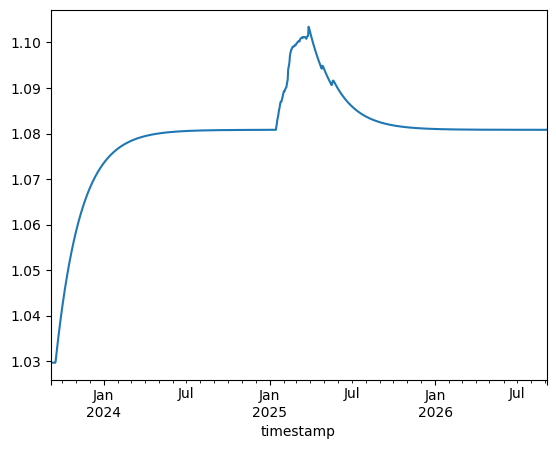

In [21]:
boni = pd.read_csv('outputs_aer/aer_scores_Boni Serrano.csv', parse_dates=['timestamp'])
print("Total bins :", len(boni))
print("Anomalies  :", boni['is_anomaly'].sum())
print("Score max  :", boni['score'].max())
print(boni.set_index('timestamp')['score'].resample('1D').max().plot())

In [22]:
boni_raw = df[df['station'] == 'Boni Serrano'].sort_values('datetime_utc')
gaps = boni_raw['datetime_utc'].diff().dt.total_seconds() / 3600
print(f"Gaps > 1h  : {(gaps > 1).sum()}")
print(f"Gaps > 24h : {(gaps > 24).sum()}")
print(f"Total span : {(boni_raw['datetime_utc'].max() - boni_raw['datetime_utc'].min()).days} days")

Gaps > 1h  : 352
Gaps > 24h : 2
Total span : 126 days


In [23]:
top = risk.head(20)
print(top[['downtime_ratio', 'anomaly_freq']].corr())

                downtime_ratio  anomaly_freq
downtime_ratio        1.000000     -0.788678
anomaly_freq         -0.788678      1.000000


In [24]:
# =============================================================
# THRESHOLD SENSITIVITY DIAGNOSTIC
# Load saved scores for one station and re-apply different thresholds.
# =============================================================
import matplotlib.pyplot as plt

STATION = 'Boni Serrano'   # change to any station of interest
SIGMAS  = [4.0, 3.5, 3.0, 2.5]

# --- Load the saved per-timestamp scores ---
safe_name = STATION.replace('/', '_').replace(',', '_')[:60]
score_path = f'{OUT_DIR}/aer_scores_{safe_name}.csv'

scores_df = pd.read_csv(score_path, parse_dates=['timestamp'])
scores    = scores_df['score'].values

print(f"Station       : {STATION}")
print(f"Total bins    : {len(scores):,}")
print(f"Score range   : [{scores.min():.3f}, {scores.max():.3f}]")
print()

# --- Reapply dynamic_threshold at each sigma ---
results = {}
for sigma in SIGMAS:
    flags = dynamic_threshold(scores, n_sigma=sigma)
    n     = int(flags.sum())
    pct   = 100.0 * n / len(scores)
    results[sigma] = flags
    print(f"σ = {sigma:.1f}   flags = {n:>5}   ({pct:>5.2f}% of bins)")

Station       : Boni Serrano
Total bins    : 78,732
Score range   : [1.030, 1.103]

σ = 4.0   flags =   378   ( 0.48% of bins)
σ = 3.5   flags =  2154   ( 2.74% of bins)
σ = 3.0   flags =  6196   ( 7.87% of bins)
σ = 2.5   flags = 12223   (15.52% of bins)


#### **Sensor Tiers**

In [25]:
# =============================================================
# SENSOR HEALTH TIERS
# Downtime thresholds are derived from EMB Memorandum Circular
# No. 2021-14, which sets a 75% minimum data capture rate for
# regulatory validity (Section 8, page 5; Annex B, page 6).
# A station below 75% capture is below the legal floor for
# monitoring data. This maps to a downtime_ratio threshold of 0.25.
#
#   75% capture = 0.25 downtime  →  CRITICAL_OFFLINE
#   90% capture = 0.10 downtime  →  DEGRADED_OFFLINE
#   95% capture = 0.05 downtime  →  OCCASIONAL_OUTAGES
#
# anomaly_freq threshold is set at the 90th percentile of the
# network, since MC 2021-14 does not define an anomaly rate
# (it defines exceedances by rolling averages against fixed limits).
# =============================================================

EMB_MIN_CAPTURE       = 0.75   # EMB MC 2021-14, Sec 8 / Annex B
EMB_BEST_PRACTICE     = 0.90   # operational target
EMB_GOOD_PRACTICE     = 0.95   # operational target

d_critical   = 1.0 - EMB_MIN_CAPTURE          # 0.25
d_degraded   = 1.0 - EMB_BEST_PRACTICE        # 0.10
d_occasional = 1.0 - EMB_GOOD_PRACTICE        # 0.05
a_suspicious = risk['anomaly_freq'].quantile(0.90)

print("Tier thresholds (derived from EMB MC 2021-14):")
print(f"  CRITICAL_OFFLINE    : downtime_ratio > {d_critical:.2f}  (below 75% capture)")
print(f"  DEGRADED_OFFLINE    : downtime_ratio > {d_degraded:.2f}  (below 90% capture)")
print(f"  OCCASIONAL_OUTAGES  : downtime_ratio > {d_occasional:.2f}  (below 95% capture)")
print(f"  SUSPICIOUS_READINGS : anomaly_freq  > {a_suspicious:.4f}  (network 90th pct)")
print()

def health_tier(row):
    d = row['downtime_ratio']
    a = row['anomaly_freq']
    if d > d_critical:      return 'CRITICAL_OFFLINE'
    if d > d_degraded:      return 'DEGRADED_OFFLINE'
    if a > a_suspicious:    return 'SUSPICIOUS_READINGS'
    if d > d_occasional:    return 'OCCASIONAL_OUTAGES'
    return 'HEALTHY'

risk['health_tier'] = risk.apply(health_tier, axis=1)

# Report
print("=== HEALTH TIER DISTRIBUTION ===")
print(risk['health_tier'].value_counts().to_string())

print("\n=== ACTION LIST BY TIER ===")
for tier in ['CRITICAL_OFFLINE', 'DEGRADED_OFFLINE',
             'SUSPICIOUS_READINGS', 'OCCASIONAL_OUTAGES']:
    subset = risk[risk['health_tier'] == tier]
    if len(subset) == 0:
        continue
    print(f"\n{tier}  ({len(subset)} stations)")
    print(subset[['predicted_risk_score', 'downtime_ratio',
                  'anomaly_freq', 'max_continuous_downtime_hours']]
            .head(10).round(3).to_string())

risk.to_csv(f'{OUT_DIR}/aer_risk_ranking.csv')

Tier thresholds (derived from EMB MC 2021-14):
  CRITICAL_OFFLINE    : downtime_ratio > 0.25  (below 75% capture)
  DEGRADED_OFFLINE    : downtime_ratio > 0.10  (below 90% capture)
  OCCASIONAL_OUTAGES  : downtime_ratio > 0.05  (below 95% capture)
  SUSPICIOUS_READINGS : anomaly_freq  > 0.0117  (network 90th pct)

=== HEALTH TIER DISTRIBUTION ===
health_tier
CRITICAL_OFFLINE       50
HEALTHY                 7
DEGRADED_OFFLINE        6
OCCASIONAL_OUTAGES      3
SUSPICIOUS_READINGS     1

=== ACTION LIST BY TIER ===

CRITICAL_OFFLINE  (50 stations)
                                                             predicted_risk_score  downtime_ratio  anomaly_freq  max_continuous_downtime_hours
station                                                                                                                                       
Boni Serrano                                                                0.649           0.583         0.005                        735.539
Ortigas Avenue-Roo